# CSCE 40103 Module 2 - Lab 1
## PHISHING URL CLASSIFICATION WITH DATA CLEANING, FEATURE PREPARATION, CROSS-VALIDATION, AND TUNING

**Dataset used:** PhiUSIIL_Phishing_URL_Dataset


## 1. Setup



In [130]:
from pathlib import Path
from io import StringIO
import base64
import gzip

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, RocCurveDisplay

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

LOCAL_CSV_PHI = Path("PhiUSIIL_Phishing_URL_Dataset.csv")
LOCAL_CSV_UNSW_TRAIN = Path("UNSW_NB15_training-set.csv")

print("Setup complete. No package installation or internet access required.")

Setup complete. No package installation or internet access required.


## 2. Load the Datasets

Load the PhiUSIIL dataset into a DataFrame named df_phish.
Load the USNW dataset into a DataFrame named df_unsw.


In [131]:
def load_phishing_dataset(local_csv: Path = LOCAL_CSV_PHI) -> pd.DataFrame:
    # Load the phishing dataset without internet or package installation.
    if local_csv.exists():
        print(f"Loading local CSV file: {local_csv}")
        loaded_df = pd.read_csv(local_csv)
    else:
        print("Local CSV not found")

    return loaded_df

df_phish = load_phishing_dataset()
print("Phish dataset loaded successfully.")
print("Shape:", df_phish.shape)
df_phish.head()

Loading local CSV file: PhiUSIIL_Phishing_URL_Dataset.csv
Phish dataset loaded successfully.
Shape: (235795, 56)


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,LineOfCode,LargestLineLength,HasTitle,Title,DomainTitleMatchScore,URLTitleMatchScore,HasFavicon,Robots,IsResponsive,NoOfURLRedirect,NoOfSelfRedirect,HasDescription,NoOfPopup,NoOfiFrame,HasExternalFormSubmit,HasSocialNet,HasSubmitButton,HasHiddenFields,HasPasswordField,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,3,1,0,0,0.0,18,0.581,0,0.0,0,0,0,1,0.032,1,558,9381,1,à¸‚à¹ˆà¸²à¸§à¸ªà¸” à¸‚à¹ˆà¸²à¸§à¸§à¸±à¸™à¸™à¸µ...,0.000000,0.000000,0,1,1,0,0,0,0,1,0,0,1,1,0,1,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,2,1,0,0,0.0,9,0.391,0,0.0,0,0,0,2,0.087,1,618,9381,1,johannes gutenberg-universitÃ¤t mainz,55.555556,55.555556,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,2,2,0,0,0.0,15,0.517,0,0.0,0,0,0,2,0.069,1,467,682,1,voice fm southampton,46.666667,46.666667,0,1,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,3,1,0,0,0.0,13,0.500,0,0.0,0,0,0,1,0.038,1,6356,26824,1,home page: seminars in fetal and neonatal medi...,0.000000,0.000000,0,1,1,0,0,0,1,12,0,1,1,1,0,0,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,3,1,0,0,0.0,20,0.606,0,0.0,0,0,0,1,0.030,1,6089,28404,1,fundaciÃ³n rewilding argentina,100.000000,100.000000,0,1,1,1,1,1,0,2,0,1,1,1,0,1,1,0,1,244,15,34,72,1,85,1


In [132]:


def load_unsw_dataset(local_csv: Path = LOCAL_CSV_UNSW_TRAIN) -> pd.DataFrame:
    # Load the phishing dataset without internet or package installation.
    if local_csv.exists():
        print(f"Loading local CSV file: {local_csv}")
        loaded_df = pd.read_csv(local_csv)
    else:
        print("Local CSV not found")
    return loaded_df

df_unsw = load_unsw_dataset()
print("UNSW dataset loaded successfully.")
print("Shape:", df_unsw.shape)
df_unsw.head()

Loading local CSV file: UNSW_NB15_training-set.csv
UNSW dataset loaded successfully.
Shape: (175341, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,252,254,14158.942380,8495.365234,0,0,24.295600,8.375000,30.177547,11.830604,255,621772692,2202533631,255,0.000000,0.000000,0.000000,43,43,0,0,1,0,1,1,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,62,252,8395.112305,503571.312500,2,17,49.915000,15.432865,61.426934,1387.778330,255,1417884146,3077387971,255,0.000000,0.000000,0.000000,52,1106,0,0,43,1,1,1,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,62,252,1572.271851,60929.230470,1,6,231.875571,102.737203,17179.586860,11420.926230,255,2116150707,2963114973,255,0.111897,0.061458,0.050439,46,824,0,0,7,1,2,1,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,62,252,2740.178955,3358.622070,1,3,152.876547,90.235726,259.080172,4991.784669,255,1107119177,1047442890,255,0.000000,0.000000,0.000000,52,64,0,0,1,1,2,1,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,254,252,8561.499023,3987.059814,2,1,47.750333,75.659602,2415.837634,115.807000,255,2436137549,1977154190,255,0.128381,0.071147,0.057234,53,45,0,0,43,1,2,2,1,40,0,0,0,2,39,0,Normal,0


## 3: Inspect the Datasets

Display the dataset size, column names, and data types for df_phish and df_unsw

In [133]:
print("Rows and columns:", df_phish.shape)
print("Column names:")
print(df_phish.columns)
print("Dataset information:")
df_phish.info()

Rows and columns: (235795, 56)
Column names:
Index(['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex',
       'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation',
       'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL',
       'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title',
       'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect',
       'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet',
       'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo',
       'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'N

In [134]:
print("Rows and columns:", df_unsw.shape)
print("Column names:")
print(df_unsw.columns)
print("Dataset information:")
df_unsw.info()

Rows and columns: (175341, 45)
Column names:
Index(['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload',
       'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt',
       'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl',
       'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd',
       'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label'],
      dtype='str')
Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  str    
 3   service      

## 4: Check Missing Values and Duplicate Rows

Check whether the datasets contain missing values and/or duplicate rows.

In [135]:
missing_values_phish = df_phish.isnull().sum()
print(missing_values_phish[missing_values_phish > 0])
duplicate_count_phish = df_phish.duplicated().sum()
print("Number of duplicate rows:", duplicate_count_phish)

Series([], dtype: int64)
Number of duplicate rows: 0


In [136]:
missing_values_unsw = df_unsw.isnull().sum()
print(missing_values_unsw[missing_values_unsw > 0])
duplicate_count_unsw = df_unsw.duplicated().sum()
print("Number of duplicate rows:", duplicate_count_unsw)

Series([], dtype: int64)
Number of duplicate rows: 0


## 5: Inspect the Target Variable

Display class counts and percentages, then create a class distribution plot

Class counts:
label
1    134850
0    100945
Name: count, dtype: int64
Class percentages:
label
1    57.19
0    42.81
Name: proportion, dtype: float64


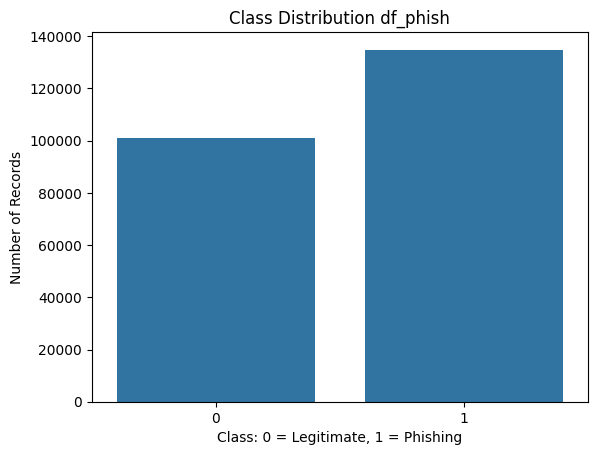

In [137]:
class_counts_phish = df_phish["label"].value_counts()
class_percentages_phish = df_phish["label"].value_counts(normalize=True) * 100
print("Class counts:")
print(class_counts_phish)
print("Class percentages:")
print(class_percentages_phish.round(2))
sns.countplot(data=df_phish, x="label")
plt.title("Class Distribution df_phish")
plt.xlabel("Class: 0 = Legitimate, 1 = Phishing")
plt.ylabel("Number of Records")
plt.show()

Class counts:
label
1    119341
0     56000
Name: count, dtype: int64
Class percentages:
label
1    68.06
0    31.94
Name: proportion, dtype: float64


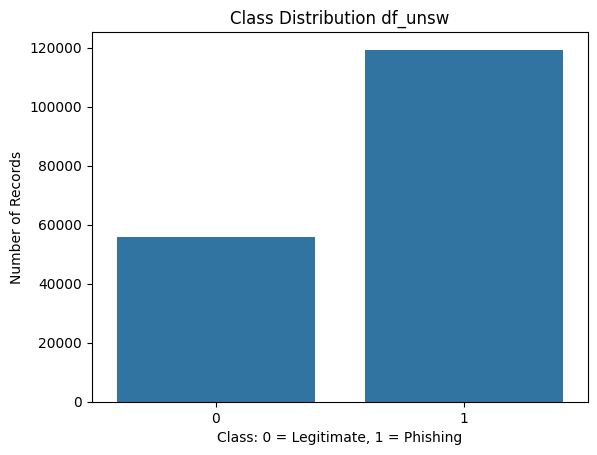

In [138]:
class_counts_unsw = df_unsw["label"].value_counts()
class_percentages_unsw = df_unsw["label"].value_counts(normalize=True) * 100
print("Class counts:")
print(class_counts_unsw)
print("Class percentages:")
print(class_percentages_unsw.round(2))
sns.countplot(data=df_unsw, x="label")
plt.title("Class Distribution df_unsw")
plt.xlabel("Class: 0 = Legitimate, 1 = Phishing")
plt.ylabel("Number of Records")
plt.show()

The class distribution for df_phish dataset is slightly imbalanced leaning more towards fishing. The df_unsw dataset appears to be quite imbalanced. In real life phishing attacks are much less common than just normal communication so this will start to bias the model towards 'thinking' there are more attacks then there really is. 

## 6: Select Useful Features

PhiUSIIL: prioritize URL structure, webpage behavior, and URL characteristics. 
UNSW-NB15: prioritize network-flow behavior and traffic characteristics.

In [139]:
candidate_features_phish = [
"URLLength",
"DomainLength",
"NoOfSubDomain",
"NoOfLettersInURL",
"NoOfDegitsInURL",
"NoOfOtherSpecialCharsInURL",
"IsHTTPS",
"NoOfExternalRef",
"LineOfCode",
"LargestLineLength"
]
selected_features_phish = []
for col in candidate_features_phish:
    if col in df_phish.columns:
        selected_features_phish.append(col)
print("Selected features:")
print(selected_features_phish)

Selected features:
['URLLength', 'DomainLength', 'NoOfSubDomain', 'NoOfLettersInURL', 'NoOfDegitsInURL', 'NoOfOtherSpecialCharsInURL', 'IsHTTPS', 'NoOfExternalRef', 'LineOfCode', 'LargestLineLength']


|Dataset|Selected Feature|Reason for Selecting It|
| --- | --- | --- |
| PhiUSIIL | ['URLLength', 'DomainLength', 'NoOfSubDomain', 'NoOfLettersInURL', 'NoOfDegitsInURL', 'NoOfOtherSpecialCharsInURL', 'IsHTTPS', 'NoOfExternalRef', 'LineOfCode', 'LargestLineLength'] |  These features prioritize url structure and characteristics (e.g. URLLength/DomainLength/NoOfLettersInUrl). It also covers URL characteristics like IsHTTPS. These are helpful for identifying anomalistic URL’s. |

In [140]:
candidate_features_unsw = [
    "dur",      # flow duration
    "spkts",    # source -> dest packet count
    "dpkts",    # dest -> source packet count
    "sbytes",   # source -> dest bytes
    "dbytes",   # dest -> source bytes
    "rate",     # packets per second
    "sload",    # source bits per second
    "dload",    # destination bits per second
    "sttl",     # source-to-dest time-to-live
    "dttl",     # dest-to-source time-to-live
]
selected_features_unsw = []
for col in candidate_features_unsw:
    if col in df_unsw.columns:
        selected_features_unsw.append(col)
print("Selected features:")
print(selected_features_unsw)

Selected features:
['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sttl', 'dttl']


|Dataset|Selected Feature|Reason for Selecting It|
| --- | --- | --- |
| UNSW-NB15 | ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sttl', 'dttl'] |   The characteristics chosen for this dataset were primarily centered around network-flow/traffic characteristics. Insight into the sttl/dttl is insightful to know how many routers the packet is hitting, spkts/dpkts helps to analyze the ratio of traffic coming and going. 

## 7: Explore Numeric Feature Distributions

Create histograms for important numeric features

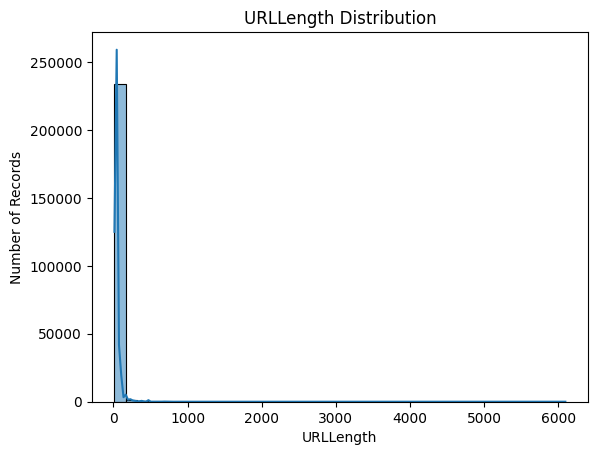

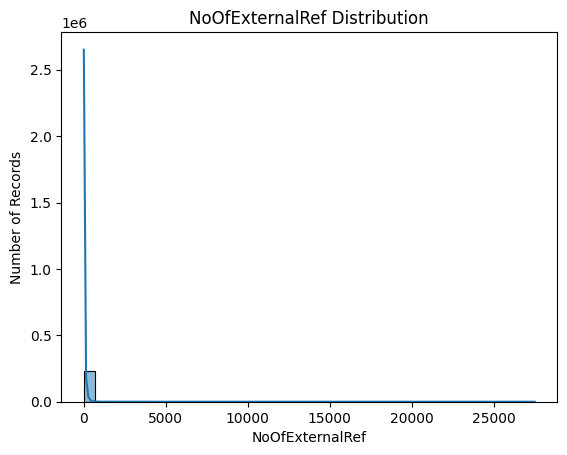

In [141]:
features_to_plot_phish = ["URLLength", "NoOfExternalRef"]
for feature in features_to_plot_phish:
    if feature in df_phish.columns:
        sns.histplot(data=df_phish, x=feature, bins=40, kde=True)
        plt.title(feature + " Distribution")
        plt.xlabel(feature)
        plt.ylabel("Number of Records")
        plt.show()

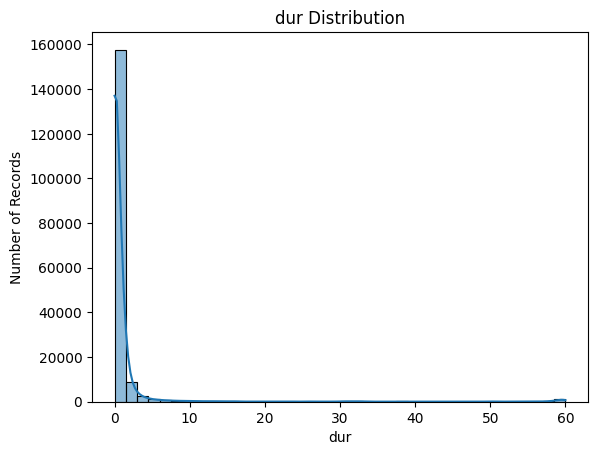

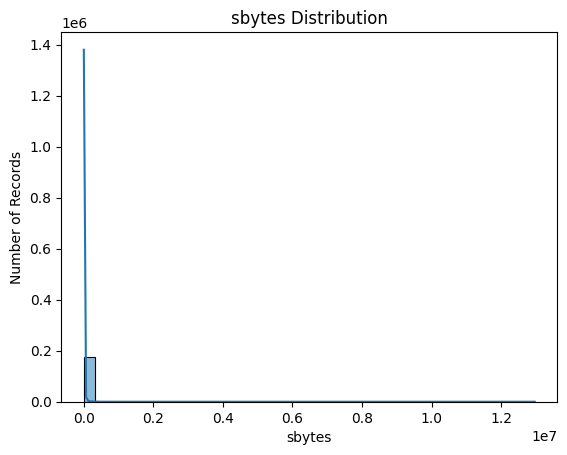

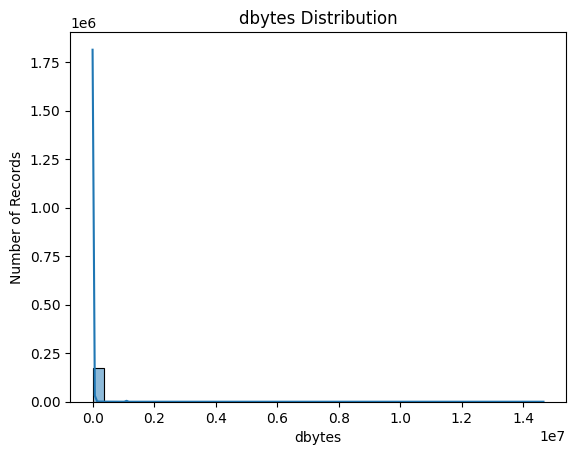

In [142]:
features_to_plot_unsw = ["dur", "sbytes", "dbytes"]
for feature in features_to_plot_unsw:
    if feature in df_unsw.columns:
        sns.histplot(data=df_unsw, x=feature, bins=40, kde=True)
        plt.title(feature + " Distribution")
        plt.xlabel(feature)
        plt.ylabel("Number of Records")
        plt.show()

## 8: Basic Feature Engineering
Create log-transformed versions of skewed numeric features.

| Dataset | Engineered Features | Formula / Description | Why It May Help |
| --- | --- | --- | --- |
| PhiUSIIL | URLLength | np.log1p(work_df["URLLength"]) | URL length is skewed, this compresses the results to prevent outliers from dominating
| PhiUSIIL | NoOfExternalRef | np.log1p(work_df["NoOfExternalRef"]) | There are a lot of zero's for this feature so this will keep 0's quantifiable. 

In [143]:
work_df_phish = df_phish.copy()
if "URLLength" in work_df_phish.columns:
    work_df_phish["log_URLLength"] = np.log1p(work_df_phish["URLLength"])
if "NoOfExternalRef" in work_df_phish.columns:
    work_df_phish["log_NoOfExternalRef"] = np.log1p(work_df_phish["NoOfExternalRef"])
work_df_phish.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,LineOfCode,LargestLineLength,HasTitle,Title,DomainTitleMatchScore,URLTitleMatchScore,HasFavicon,Robots,IsResponsive,NoOfURLRedirect,NoOfSelfRedirect,HasDescription,NoOfPopup,NoOfiFrame,HasExternalFormSubmit,HasSocialNet,HasSubmitButton,HasHiddenFields,HasPasswordField,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label,log_URLLength,log_NoOfExternalRef
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,3,1,0,0,0.0,18,0.581,0,0.0,0,0,0,1,0.032,1,558,9381,1,à¸‚à¹ˆà¸²à¸§à¸ªà¸” à¸‚à¹ˆà¸²à¸§à¸§à¸±à¸™à¸™à¸µ...,0.000000,0.000000,0,1,1,0,0,0,0,1,0,0,1,1,0,1,0,0,1,34,20,28,119,0,124,1,3.465736,4.828314
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,2,1,0,0,0.0,9,0.391,0,0.0,0,0,0,2,0.087,1,618,9381,1,johannes gutenberg-universitÃ¤t mainz,55.555556,55.555556,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,50,9,8,39,0,217,1,3.178054,5.384495
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,2,2,0,0,0.0,15,0.517,0,0.0,0,0,0,2,0.069,1,467,682,1,voice fm southampton,46.666667,46.666667,0,1,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,10,2,7,42,2,5,1,3.401197,1.791759
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,3,1,0,0,0.0,13,0.500,0,0.0,0,0,0,1,0.038,1,6356,26824,1,home page: seminars in fetal and neonatal medi...,0.000000,0.000000,0,1,1,0,0,0,1,12,0,1,1,1,0,0,1,1,1,3,27,15,22,1,31,1,3.295837,3.465736
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,3,1,0,0,0.0,20,0.606,0,0.0,0,0,0,1,0.030,1,6089,28404,1,fundaciÃ³n rewilding argentina,100.000000,100.000000,0,1,1,1,1,1,0,2,0,1,1,1,0,1,1,0,1,244,15,34,72,1,85,1,3.526361,4.454347


| Dataset | Engineered Features | Formula / Description | Why It May Help |
| --- | --- | --- | --- |
| UNSW-NB15 | sbytes and dbytes ratio | work_df_unsw["sbytes"] / (work_df_unsw["dbytes"] + 1)  | This will help get a better idea of the bytes flowing.
| UNSW-NB15 | NoOfExternalRef | np.log1p(work_df["NoOfExternalRef"]) | duration is heavily skewed, this should help compress the data. 

In [144]:
work_df_unsw = df_unsw.copy()
if "sbytes" in work_df_unsw.columns and "dbytes" in work_df_unsw.columns:
    work_df_unsw["byte_ratio"] = np.log1p(work_df_unsw["sbytes"]) / np.log1p(work_df_unsw["dbytes"]) 
if "dur" in work_df_unsw.columns:
    work_df_unsw["log_dur"] = np.log1p(work_df_unsw["dur"])
work_df_unsw.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label,byte_ratio,log_dur
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,252,254,14158.942380,8495.365234,0,0,24.295600,8.375000,30.177547,11.830604,255,621772692,2202533631,255,0.000000,0.000000,0.000000,43,43,0,0,1,0,1,1,1,1,0,0,0,1,1,0,Normal,0,1.078307,0.114647
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,62,252,8395.112305,503571.312500,2,17,49.915000,15.432865,61.426934,1387.778330,255,1417884146,3077387971,255,0.000000,0.000000,0.000000,52,1106,0,0,43,1,1,1,1,2,0,0,0,1,6,0,Normal,0,0.619952,0.500716
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,62,252,1572.271851,60929.230470,1,6,231.875571,102.737203,17179.586860,11420.926230,255,2116150707,2963114973,255,0.111897,0.061458,0.050439,46,824,0,0,7,1,2,1,1,3,0,0,0,2,6,0,Normal,0,0.621894,0.964368
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,62,252,2740.178955,3358.622070,1,3,152.876547,90.235726,259.080172,4991.784669,255,1107119177,1047442890,255,0.000000,0.000000,0.000000,52,64,0,0,1,1,2,1,1,3,1,1,0,2,1,0,Normal,0,0.969379,0.986429
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,254,252,8561.499023,3987.059814,2,1,47.750333,75.659602,2415.837634,115.807000,255,2436137549,1977154190,255,0.128381,0.071147,0.057234,53,45,0,0,43,1,2,2,1,40,0,0,0,2,39,0,Normal,0,1.122894,0.371187


## 9: Compare Raw and Log-Transformed Values
Create raw and log-transformed histograms for URLLength.

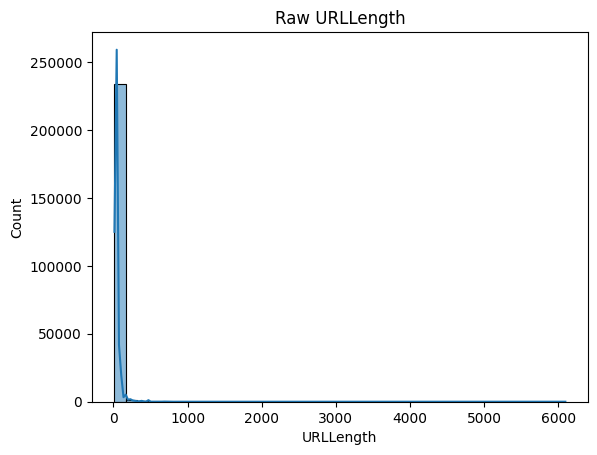

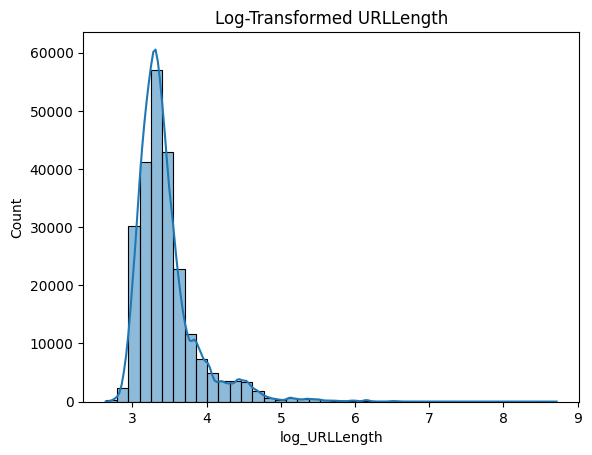

In [145]:
if "URLLength" in work_df_phish.columns:
    sns.histplot(data=work_df_phish, x="URLLength", bins=40, kde=True)
    plt.title("Raw URLLength")
    plt.show()
    sns.histplot(data=work_df_phish, x="log_URLLength", bins=40, kde=True)
    plt.title("Log-Transformed URLLength")
    plt.show()

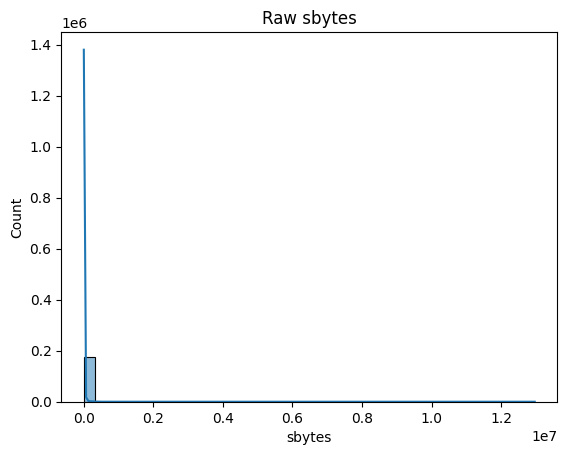

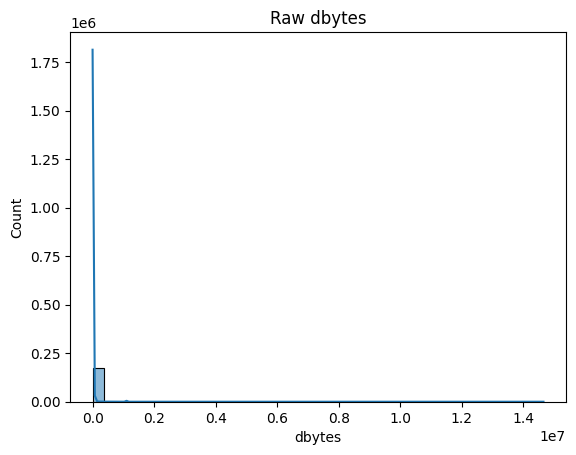

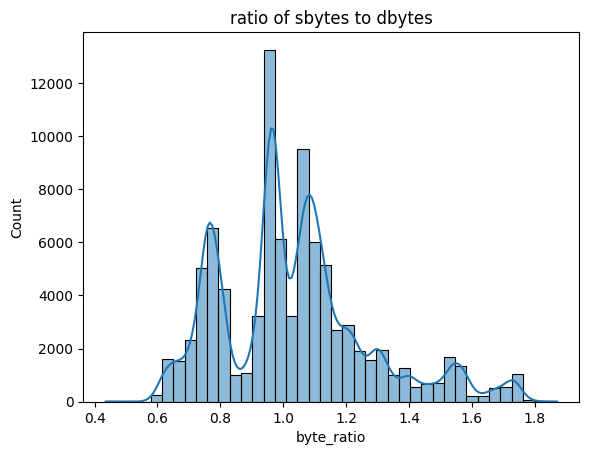

In [146]:
if "sbytes" in work_df_unsw.columns:
    sns.histplot(data=work_df_unsw, x="sbytes", bins=40, kde=True)
    plt.title("Raw sbytes")
    plt.show()
if "dbytes" in work_df_unsw.columns:
    sns.histplot(data=work_df_unsw, x="dbytes", bins=40, kde=True)
    plt.title("Raw dbytes")
    plt.show()
    sns.histplot(data=work_df_unsw, x="byte_ratio", bins=40, kde=True)
    plt.title("ratio of sbytes to dbytes")
    plt.show()
else:
    print("dbytes column not found, unable to produce histogram")

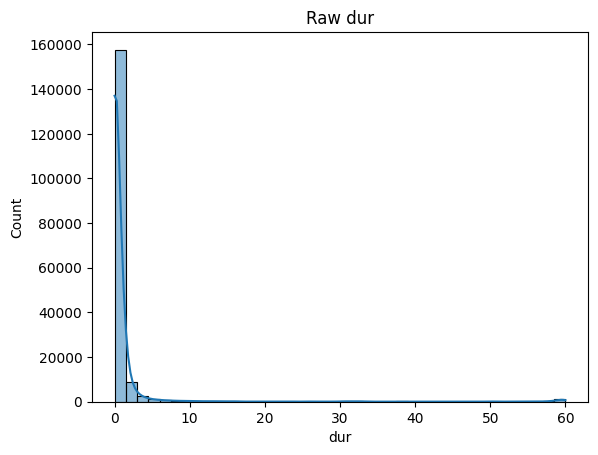

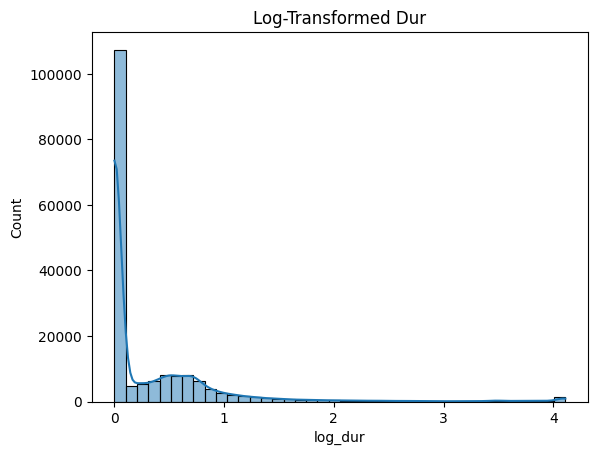

In [147]:
if "dur" in work_df_unsw.columns:
    sns.histplot(data=work_df_unsw, x="dur", bins=40, kde=True)
    plt.title("Raw dur")
    plt.show()
    sns.histplot(data=work_df_unsw, x="log_dur", bins=40, kde=True)
    plt.title("Log-Transformed Dur")
    plt.show()

## 10: Update the Feature List
Add the engineered features to the selected feature list.

In [150]:
final_features_phish = selected_features_phish.copy()
if "log_URLLength" in work_df_phish.columns:
    final_features_phish.append("log_URLLength")
if "log_NoOfExternalRef" in work_df_phish.columns:
    final_features_phish.append("log_NoOfExternalRef")
print("Final features:")
print(final_features_phish)

Final features:
['URLLength', 'DomainLength', 'NoOfSubDomain', 'NoOfLettersInURL', 'NoOfDegitsInURL', 'NoOfOtherSpecialCharsInURL', 'IsHTTPS', 'NoOfExternalRef', 'LineOfCode', 'LargestLineLength', 'log_URLLength', 'log_NoOfExternalRef']


In [151]:
final_features_unsw = selected_features_unsw.copy()
if "log_dur" in work_df_unsw.columns:
    final_features_unsw.append("log_dur")
print("Final features:")
print(final_features_unsw)

Final features:
['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sttl', 'dttl', 'log_dur']


## 11: Correlation Analysis
Create a correlation heatmap using the final numeric features and the label

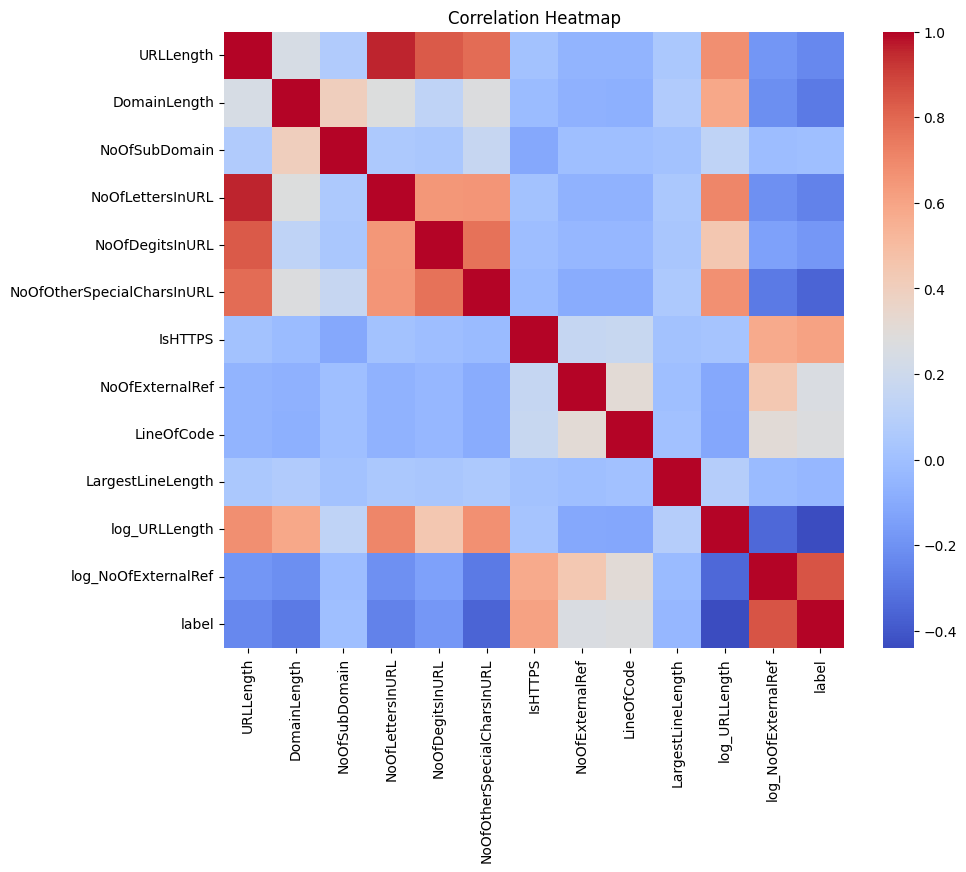

In [153]:
corr_phish = work_df_phish[final_features_phish + ["label"]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_phish, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In this heat map it looks like the log_NoOfExternalRef and label correlate as well as NoOfDegitsInUrl and NoOfOtherSpecialCharsInURL. URLLength and log_URLLength are redundant since they are providing the same information. 

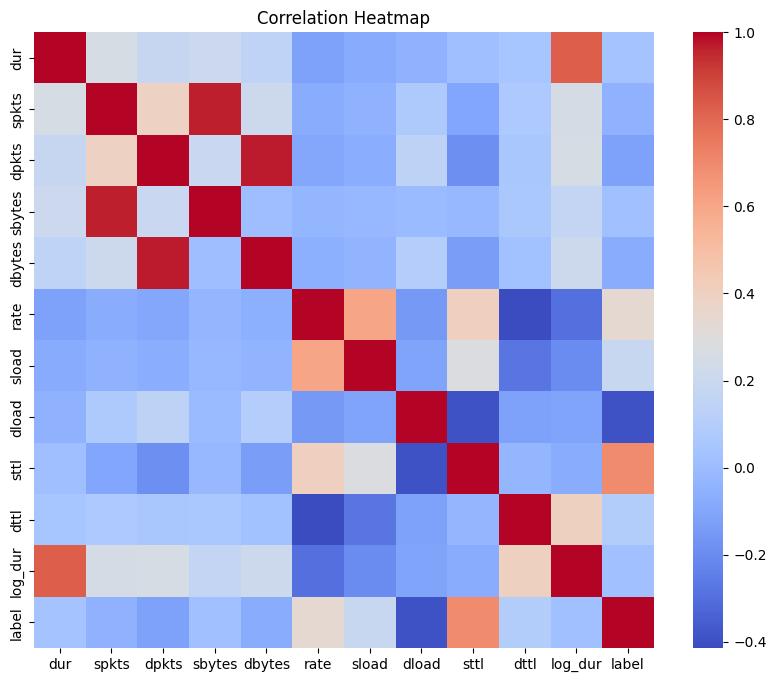

In [154]:
corr_unsw = work_df_unsw[final_features_unsw + ["label"]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_unsw, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

There is a strong correlation between dload and sttl as well as dload and label. dur is now redundant because of log_dur. 

## 12: Create X and y

Create the feature matrix X and target vector y

In [ ]:
X_phish = work_df_phish[final_features_phish]
y_phish = work_df_phish["label"]
print("X shape:", X_phish.shape)
print("y shape:", y_phish.shape)

X_unsw = work_df_unsw[final_features_unsw]
y_unsw = work_df_unsw["label"]
print("X shape:", X_unsw.shape)
print("y shape:", y_unsw.shape)

## 13: Train-Test Split

Split the data into training and testing sets. Use stratify=y to preserve class proportions

In [ ]:
def trainTestSplit(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=40103
    )
    print("Training rows:", X_train.shape[0])
    print("Testing rows:", X_test.shape[0])
    print("Training class distribution:")
    print(y_train.value_counts(normalize=True).round(3))
    print("Testing class distribution:")
    print(y_test.value_counts(normalize=True).round(3))
    return X_train, X_test, y_train, y_test

X_train_phish, X_test_phish, y_train_phish, y_test_phish = trainTestSplit(X_phish, y_phish)

## 14: Fill Missing Values

Use the training median to fill missing values. Use the same training median for the test set.

In [ ]:
train_medians_phish = X_train_phish.median()
X_train_clean_phish = X_train_phish.fillna(train_medians_phish)
X_test_clean_phish = X_test_phish.fillna(train_medians_phish)
print("Missing values in X_train_clean_phish:", X_train_clean_phish.isnull().sum().sum())
print("Missing values in X_test_clean_phish:", X_test_clean_phish.isnull().sum().sum())

## 15: Scale Numeric Features

Scale the features using StandardScaler. Fit the scaler only on the training data.

In [ ]:
scaler = StandardScaler()
X_train_scaled_phish = scaler.fit_transform(X_train_clean_phish)
X_test_scaled_phish = scaler.transform(X_test_clean_phish)
print("Scaled training shape:", X_train_scaled_phish.shape)
print("Scaled testing shape:", X_test_scaled_phish.shape)

## 16: Train Logistic Regression

Create, train, and evaluate a Logistic Regression model.

In [ ]:
log_model = LogisticRegression(
max_iter=1000,
class_weight="balanced",
random_state=40103
)
log_model.fit(X_train_scaled_phish, y_train_phish)
log_pred = log_model.predict(X_test_scaled_phish)
print(classification_report(y_test_phish, log_pred, zero_division=0))
log_cm = confusion_matrix(y_test_phish, log_pred)
disp = ConfusionMatrixDisplay(
confusion_matrix=log_cm,
display_labels=["Legitimate", "Phishing"]
)
disp.plot(values_format="d")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

## 17: Train Decision Tree

Create, train, and evaluate a Decision Tree model.

In [ ]:
tree_model = DecisionTreeClassifier(
random_state=40103,
class_weight="balanced"
)
tree_model.fit(X_train_clean, y_train)
tree_pred = tree_model.predict(X_test_clean)
print(classification_report(y_test, tree_pred, zero_division=0))
tree_cm = confusion_matrix(y_test, tree_pred)
disp = ConfusionMatrixDisplay(
confusion_matrix=tree_cm,
display_labels=["Legitimate", "Phishing"]
)
disp.plot(values_format="d")
plt.title("Decision Tree Confusion Matrix")
plt.show()

## 18: Create a Metric Summary Table

Create a function to compute model metrics and display a comparison table.
get_metrics()

In [ ]:
def get_metrics(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0)
    }
results = [
    get_metrics("Logistic Regression", y_test, log_pred),
    get_metrics("Decision Tree", y_test, tree_pred)
]
results_df = pd.DataFrame(results)
results_df

## 19: Stratified k-Fold Cross-Validation

Use stratified 5-fold cross-validation to compare the two models more reliably.

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=40103
)
scoring = ["accuracy", "precision", "recall", "f1"]
X_clean = X.fillna(X.median())
X_scaled = scaler.fit_transform(X_clean)
log_cv = cross_validate(
 log_model,
 X_scaled,
 y,
 cv=cv,
 scoring=scoring
)
tree_cv = cross_validate(
    tree_model,
    X_clean,
    y,
    cv=cv,
    scoring=scoring
)
cv_summary = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": log_cv["test_accuracy"].mean(),
        "Precision": log_cv["test_precision"].mean(),
        "Recall": log_cv["test_recall"].mean(),
        "F1": log_cv["test_f1"].mean()
    },
    {
        "Model": "Decision Tree",
        "Accuracy": tree_cv["test_accuracy"].mean(),
        "Precision": tree_cv["test_precision"].mean(),
        "Recall": tree_cv["test_recall"].mean(),
        "F1": tree_cv["test_f1"].mean()
    }
])
cv_summary

## 20: Hyperparameter Tuning for Decision Tree
Tune only the Decision Tree model. Random Forest is not used in this lab.

In [ ]:
param_grid = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}
tree_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=40103,
        class_weight="balanced"
    ),
    param_grid=param_grid,
    cv=cv,
    scoring="f1"
)
tree_grid.fit(X_train_clean, y_train)
print("Best parameters:")
print(tree_grid.best_params_)
print("Best cross-validation F1:")
print(tree_grid.best_score_)

## 21: Evaluate the Tuned Decision Tree
Use the best Decision Tree model to predict the test set.

In [ ]:
best_tree = tree_grid.best_estimator_
tuned_tree_pred = best_tree.predict(X_test_clean)
print(classification_report(y_test, tuned_tree_pred, zero_division=0))
tuned_cm = confusion_matrix(y_test, tuned_tree_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=tuned_cm,
    display_labels=["Legitimate", "Phishing"]
)
disp.plot(values_format="d")
plt.title("Tuned Decision Tree Confusion Matrix")
plt.show()

## 22: Final Comparison Table
Create a final table comparing all three model versions

In [ ]:
final_results = [
    get_metrics("Logistic Regression", y_test, log_pred),
    get_metrics("Decision Tree", y_test, tree_pred),
    get_metrics("Tuned Decision Tree", y_test, tuned_tree_pred)
]
final_results_df = pd.DataFrame(final_results)
final_results_df